# Tokenization analysis for genetic variants — no evaluation file required

This notebook lets you evaluate **how genetic variants are tokenized** even before receiving `LLM_evaluation_statistics.csv`.

It focuses on three things:

1. inspect tokenization of specific variant strings;
2. extract candidate variant mentions from titles/abstracts using regex;
3. compare tokenization complexity across tokenizers/models.

Later, when `LLM_evaluation_statistics.csv` becomes available, you can add recall/error analysis on top of this notebook.


## 1. Imports and configuration

Set the paths and tokenizer names here. The notebook works with only `binary_cancer_matrix_filtered.csv`.


In [1]:
# If needed, uncomment and run:
# !pip install pandas numpy matplotlib transformers tqdm openpyxl

import os
import re
import json
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from transformers import AutoTokenizer

from dotenv import load_dotenv

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 100)

load_dotenv()
print("Imports loaded.")

warnings.filterwarnings("ignore")

# -----------------------------
# PATHS
# -----------------------------
DATA_DIR = Path(".")
INPUT_DIRECTORY = os.getenv("INPUT_DIRECTORY", ".")
input_path = Path(INPUT_DIRECTORY)

# Change this if your file is elsewhere
ARTICLE_FILE = input_path / "binary_cancer_matrix_filtered.csv"

# Optional outputs
OUTPUT_DIR = DATA_DIR / "tokenizer_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# -----------------------------
# TOKENIZERS TO TEST
# -----------------------------
# You can add/remove tokenizers depending on what is available in your environment.
TOKENIZER_NAMES = {
    "qwen2.5": "Qwen/Qwen2.5-0.5B",
    "llama33_70b": "meta-llama/Llama-3.3-70B-Instruct",
    "llama31_70b": "meta-llama/Meta-Llama-3.1-70B-Instruct",
    # Biomedical / BERT-like examples:
    # "biobert": "dmis-lab/biobert-base-cased-v1.1",
    # "pubmedbert": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext",
}

MAIN_TOKENIZER_KEY = "llama33_70b"
MAIN_TOKENIZER_NAME = TOKENIZER_NAMES[MAIN_TOKENIZER_KEY]

print("Main tokenizer:", MAIN_TOKENIZER_NAME)
print("Article file:", ARTICLE_FILE.resolve())
print("Output folder:", OUTPUT_DIR.resolve())


Imports loaded.
Main tokenizer: meta-llama/Llama-3.3-70B-Instruct
Article file: /Users/andreiblindu/Desktop/Idiap/code/Variantscape/results_openalex/04_categorization/binary_cancer_matrix_filtered.csv
Output folder: /Users/andreiblindu/Desktop/Idiap/code/Variantscape/notebooks/05_LLM_variant_extraction/tokenizer_outputs


## 2. Load article/title/abstract data

This step does **not** require `LLM_evaluation_statistics.csv`.


In [2]:
if not ARTICLE_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {ARTICLE_FILE}. Put binary_cancer_matrix_filtered.csv in the current folder "
        "or update ARTICLE_FILE above."
    )

articles = pd.read_csv(ARTICLE_FILE)
print("Shape:", articles.shape)
print("Columns:", list(articles.columns))
display(articles.head())


Shape: (14500, 905)
Columns: ['PaperId', 'PaperTitle', 'Citations', 'CoFoS', 'Authors', 'Abstract', 'Language', 'PubYear', 'PubDate', 'BioBERT', 'Gene ID', '4244', '16656', '16535', '6906', '7451', '4', '101', '13602', '128', '130', '150', '154', '221', '8407', '6394', '2', '254', '7936', '259', '7024', '1', '18420', '327', '28004', '6845', '66', '67', '3', '389', '9279', '2438', '6559', '19838', '436', '446', '450', '68', '69', '519', '524', '525', '22231', '5112', '61', '7282', '6572', '533', '537', '17817', '2239', '14160', '70', '549', '550', '7074', '12133', '59', '7953', '566', '567', '12555', '353', '355', '13783', '14842', '594', '608', '5', '6', '7', '9588', '15955', '638', '6317', '65', '732', '16180', '14329', '761', '21153', '778', '779', '9705', '1283', '8', '9', '10', '11', '7222', '826', '11335', '855', '859', '864', '868', '7351', '8132', '19300', '888', '12112', '906', '13', '908', '12', '912', '913', '914', '14', '916', '29688', '927', '588', '3798', '15', '938', '127

,PaperId,PaperTitle,Citations,CoFoS,Authors,Abstract,Language,PubYear,PubDate,BioBERT,Gene ID,4244,16656,16535,6906,7451,4,101,13602,128,130,150,154,221,8407,6394,2,254,7936,259,7024,1,18420,327,28004,6845,66,67,3,389,9279,2438,6559,19838,436,446,450,68,69,519,...,osteosarcoma,ovarian cancer,ovarian clear cell cancer,ovarian serous cancer,ovarian serous cystadenocarcinoma,pancreatic adenocarcinoma,pancreatic cancer,pancreatic ductal adenocarcinoma,pancreatic ductal cancer,papillary adenocarcinoma,papillary renal cell cancer,papillary thyroid cancer,paraganglioma,pediatric glioma,peritoneal cancer,peritoneal mesothelioma,pilocytic astrocytoma,pleomorphic xanthoastrocytoma,plexiform neurofibroma,prostate adenocarcinoma,prostate cancer,pseudomyxoma peritonei,renal cancer,renal cell cancer,renal medullary cancer,retinoblastoma,rhabdoid cancer,rhabdomyosarcoma,salivary gland adenoid cystic cancer,salivary gland cancer,salivary gland mucoepidermoid cancer,sarcoma,sinonasal undifferentiated cancer,skin melanoma,skin squamous cell cancer,spindle cell sarcoma,splenomegaly,squamous cell cancer,stomach cancer,synovial sarcoma,thymic cancer,thyroid cancer,transitional cell cancer,urinary bladder cancer,urothelial cancer,uterine cancer,uterine corpus endometrial cancer,uterine leiomyosarcoma,uveal melanoma,Cancer_Type_Sum
0,7106250716,PVNDMVLiver Circuit Drives Hepatocellular Carcinoma Progression in the Context of Depression Comorbidity,0,50738837|2778019345|71924100|96525457|2779343474|2777731756|126322002|2776867660|2779256057|2780648746|164027704|22885893|2779159551|502942594|162317418|143998085|17991360|169760540|2776107976|277...,"Chi, Dongmei","Hepatocellular carcinoma (HCC) and depression frequently co-occur, yet whether and how depression affects HCC progression is unknown. Here, we show that stress-induced mouse depression models, chr...",en,2026,2026-11-20,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,7119160011,Screening and biological function analysis of differentially expressed genes associated with miR-21 in hepatocellular carcinoma tissue,0,152724338|86803240|104317684|2778019345|14036430|70721500|2987395477|127561419|8891405|141231307|9927688|150194340|54355233|121608353|502942594|60644358|162317418|18431079|10515644|165864922|67339327,"SUN Chenggong, TIAN Ying, JIANG Feng","Objective To investigate the differentially expressed genes (DEGs) associated with miR-21 between hepatocellular carcinoma (HCC) tissue and normal tissue, as well as their biological function in t...",en,2026,2026-02-01,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,7125102904,"Recent advances in non-alcoholic steatohepatitis-associated hepatocellular carcinoma: immune cells, metabolic dysregulation, and therapeutic strategies",4388775059|4395449374|4292185004|4225867561|3163776584|3009648964|4319298087|4309928137|4210527350|4285809169|3020992657|3202114749|3160314721|4413434624|4220784693|4411437443|4412751594|428574439...,8891405|2776914184|2777701055|71924100|502942594|2779478299|203014093|2778690821|2778019345|2778772119|2780559512|180899940|60644358|136449434|62478195|2991678113|86803240|2779134260|4733338|27793...,"Lisi Liu, Xun Duan, Baozhao Ju","Non-alcoholic steatohepatitis (NASH), the inflammatory progression of non-alcoholic fatty liver disease (NAFLD), is a leading cause of hepatocellular carcinoma (HCC) amid rising obesity and metabo...",en,2026,2026-01-21,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0

In [3]:
# Try to infer common column names.
# Edit these if your columns have different names.
ID_COL = "PaperId" if "PaperId" in articles.columns else articles.columns[0]
TITLE_COL = "PaperTitle" if "PaperTitle" in articles.columns else None
ABSTRACT_COL = "Abstract" if "Abstract" in articles.columns else None

print("ID_COL:", ID_COL)
print("TITLE_COL:", TITLE_COL)
print("ABSTRACT_COL:", ABSTRACT_COL)

if ABSTRACT_COL is None:
    raise ValueError("No 'Abstract' column found. Please set ABSTRACT_COL manually.")

# Combined text used for candidate extraction
articles["text_for_variant_search"] = (
    articles[TITLE_COL].fillna("").astype(str) + " " + articles[ABSTRACT_COL].fillna("").astype(str)
    if TITLE_COL is not None
    else articles[ABSTRACT_COL].fillna("").astype(str)
)


ID_COL: PaperId
TITLE_COL: PaperTitle
ABSTRACT_COL: Abstract


## 3. Load a tokenizer and inspect individual variants

Start with manually chosen examples. This is the most direct way to understand how variant forms are split.


In [ ]:
from huggingface_hub import login

login("")

tokenizer = AutoTokenizer.from_pretrained(
    MAIN_TOKENIZER_NAME,
    use_fast=True,
    trust_remote_code=True
)

print("Loaded tokenizer:", MAIN_TOKENIZER_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Fast tokenizer:", tokenizer.is_fast)


Loaded tokenizer: meta-llama/Llama-3.3-70B-Instruct
Tokenizer class: PreTrainedTokenizerFast
Fast tokenizer: True


In [12]:
new_tokens = [
    "c.", "p.", "g.", "m.", "n.", "r.",
    "del", "dup", "ins", "delins", "fs", "Ter",
    "rs",
    "Ala", "Arg", "Asn", "Asp", "Cys", "Gln", "Glu", "Gly",
    "His", "Ile", "Leu", "Lys", "Met", "Phe", "Pro", "Ser",
    "Thr", "Trp", "Tyr", "Val",
    ">", "_", ":",
    "BRCA1", "BRAF", "KRAS"
]

tokenizer.add_tokens(new_tokens)

0

In [13]:
def inspect_tokenization(text, tokenizer, add_special_tokens=False):
    """
    Return a token-level table with offsets and visible text pieces.
    """
    text = str(text)
    enc = tokenizer(
        text,
        add_special_tokens=add_special_tokens,
        return_offsets_mapping=True
    )
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    offsets = enc["offset_mapping"]

    rows = []
    for i, (tok, tok_id, offset) in enumerate(zip(tokens, enc["input_ids"], offsets)):
        start, end = offset
        rows.append({
            "token_index": i,
            "token": tok,
            "token_id": tok_id,
            "char_start": start,
            "char_end": end,
            "text_piece": text[start:end] if end > start else "",
        })
    return pd.DataFrame(rows)

manual_variants = [
    "BRCA1 c.68_69delAG",
    "c.5266dupC",
    "p.Val600Glu",
    "V600E",
    "BRAF V600E",
    "rs121913529",
    "185delAG",
    "5382insC",
    "EGFR exon 19 deletion",
    "c.1799T>A",
    "p.Gly12Asp",
    "KRAS G12D",
    "NM_004333.6:c.1799T>A",
]

for variant in manual_variants:
    print("\n" + "="*100)
    print(variant)
    display(inspect_tokenization(variant, tokenizer))



BRCA1 c.68_69delAG


,token_index,token,token_id,char_start,char_end,text_piece
0,0,BRCA1,128276,0,5,BRCA1
1,1,Ġ,220,5,6,
2,2,c.,128256,6,8,c.
3,3,68,2614,8,10,68
4,4,_,62,10,11,_
5,5,69,3076,11,13,69
6,6,del,9783,13,16,del
7,7,AG,1929,16,18,AG



c.5266dupC


,token_index,token,token_id,char_start,char_end,text_piece
0,0,c.,128256,0,2,c.
1,1,526,22593,2,5,526
2,2,6,21,5,6,6
3,3,dup,22675,6,9,dup
4,4,C,34,9,10,C



p.Val600Glu


...

,token_index,token,token_id,char_start,char_end,text_piece
0,0,p.,128257,0,2,p.
1,1,Gly,128269,2,5,Gly
2,2,12,717,5,7,12
3,3,Asp,128265,7,10,Asp



KRAS G12D


,token_index,token,token_id,char_start,char_end,text_piece
0,0,KRAS,128278,0,4,KRAS
1,1,ĠG,480,4,6,G
2,2,12,717,6,8,12
3,3,D,35,8,9,D



NM_004333.6:c.1799T>A


,token_index,token,token_id,char_start,char_end,text_piece
0,0,NM,38425,0,2,NM
1,1,_,62,2,3,_
2,2,004,8759,3,6,004
3,3,333,8765,6,9,333
4,4,.,13,9,10,.
5,5,6,21,10,11,6
6,6,:,25,11,12,:
7,7,c.,128256,12,14,c.
8,8,179,11128,14,17,179
9,9,9,24,17,18,9


## 4. Compute tokenization complexity features

These features let you rank variants by fragmentation.


In [14]:
def tokenization_features(variant, tokenizer):
    """
    Compute tokenization-fragmentation features for a variant string.
    Also evaluates the string with a leading space because many tokenizers behave differently at word boundaries.
    """
    variant = str(variant).strip()
    if not variant:
        return None

    result = {"variant": variant, "n_chars": len(variant)}

    for mode, text in {"raw": variant, "leading_space": " " + variant}.items():
        enc = tokenizer(
            text,
            add_special_tokens=False,
            return_offsets_mapping=True
        )
        tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])
        pieces = [text[s:e] for s, e in enc["offset_mapping"]]
        n_tokens = len(tokens)

        result[f"n_tokens_{mode}"] = n_tokens
        result[f"chars_per_token_{mode}"] = len(text) / n_tokens if n_tokens else np.nan
        result[f"tokens_{mode}"] = tokens
        result[f"pieces_{mode}"] = pieces

    result["fragmentation_ratio"] = result["n_tokens_raw"] / max(len(variant), 1)
    result["has_punctuation"] = bool(re.search(r"[.\->_/+:]", variant))
    result["has_digit"] = bool(re.search(r"\d", variant))
    result["has_mixed_case"] = bool(re.search(r"[a-z]", variant) and re.search(r"[A-Z]", variant))
    result["has_hgvs_prefix"] = bool(re.search(r"\b[cpgnmr]\.\"", variant, flags=re.IGNORECASE))
    result["has_refseq_like_id"] = bool(re.search(r"\bN[MCGR]_[0-9]+(?:\.[0-9]+)?", variant))
    result["contains_del_dup_ins"] = bool(re.search(r"del|dup|ins", variant, flags=re.IGNORECASE))

    return result

manual_features = pd.DataFrame([tokenization_features(v, tokenizer) for v in manual_variants])
manual_features = manual_features.sort_values(["n_tokens_raw", "fragmentation_ratio"], ascending=False)

display(manual_features[[
    "variant", "n_chars", "n_tokens_raw", "chars_per_token_raw",
    "fragmentation_ratio", "has_punctuation", "has_hgvs_prefix",
    "contains_del_dup_ins", "tokens_raw"
]])


,variant,n_chars,n_tokens_raw,chars_per_token_raw,fragmentation_ratio,has_punctuation,has_hgvs_prefix,contains_del_dup_ins,tokens_raw
12,NM_004333.6:c.1799T>A,21,13,1.615385,0.619048,True,False,False,"[NM, _, 004, 333, ., 6, :, c., 179, 9, T, >, A]"
8,EGFR exon 19 deletion,21,9,2.333333,0.428571,False,False,True,"[EG, FR, Ġexon, Ġ, 19, Ġ, del, et, ion]"
0,BRCA1 c.68_69delAG,18,8,2.250000,0.444444,True,False,True,"[BRCA1, Ġ, c., 68, _, 69, del, AG]"
9,c.1799T>A,9,6,1.500000,0.666667,True,False,False,"[c., 179, 9, T, >, A]"
1,c.5266dupC,10,5,2.000000,0.500000,True,False,True,"[c., 526, 6, dup, C]"
7,5382insC,8,4,2.000000,0.500000,False,False,True,"[538, 2, ins, C]"
11,KRAS G12D,9,4,2.250000,0.444444,False,False,False,"[KRAS, ĠG, 12, D]"
4,BRAF V600E,10,4,2.500000,0.400000,False,False,False,"[BRAF, ĠV, 600, E]"
10,p.Gly12Asp,10,4,2.500000,0.400000,True,False,False,"[p., Gly, 12, Asp]"
2,p.Val600Glu,11,4,2.750000,0.363636,True,False,False,"[p., Val, 600, Glu]"


## 5. Extract candidate variants from titles and abstracts

Since you do not yet have the evaluation file, this section uses regex patterns to create a provisional list of candidate variant mentions from the corpus.

This is not a gold-standard NER evaluation. It is a **tokenization diagnostic** over likely variant strings.


In [28]:
# Regex patterns for common variant-like strings.
# You can make these stricter or broader depending on your corpus.

VARIANT_PATTERNS = {
    "rs_id": r"\brs\d+\b",
    "coding_substitution": r"\bc\.\d+(?:_\d+)?[ACGT]>[ACGT]\b",
    "coding_indel": r"\bc\.\d+(?:_\d+)?(?:del|dup|ins)[A-Za-z0-9]*\b",
    "protein_three_letter": r"\bp\.[A-Z][a-z]{2}\d+[A-Z][a-z]{2}\b",
    "protein_one_letter_with_p": r"\bp\.[A-Z]\d+[A-Z]\b",
    "gene_plus_protein": r"\b[A-Z0-9]{2,10}\s+[A-Z]\d+[A-Z]\b",
    "protein_one_letter": r"\b[A-Z]\d+[A-Z]\b",
    "legacy_indel": r"\b\d+(?:del|ins|dup)[A-Za-z0-9]*\b",
    "refseq_hgvs": r"\bN[MCGR]_[0-9]+(?:\.[0-9]+)?:[cgmnpr]\.\S+\b",
}

COMBINED_VARIANT_REGEX = re.compile(
    "|".join(f"(?P<{name}>{pattern})" for name, pattern in VARIANT_PATTERNS.items()),
    flags=re.IGNORECASE
)

def extract_candidate_variants(text):
    rows = []
    if pd.isna(text):
        return rows

    text = str(text)
    for match in COMBINED_VARIANT_REGEX.finditer(text):
        variant = match.group(0).strip(".,;:()[]{}")
        if not variant:
            continue
        rows.append({
            "candidate_variant": variant,
            "match_type": match.lastgroup,
            "char_start": match.start(),
            "char_end": match.end(),
            "context": text[max(0, match.start()-80): min(len(text), match.end()+80)]
        })
    return rows

candidate_rows = []
for _, row in tqdm(articles.iterrows(), total=len(articles)):
    for m in extract_candidate_variants(row["text_for_variant_search"]):
        m[ID_COL] = row[ID_COL]
        if TITLE_COL is not None:
            m[TITLE_COL] = row[TITLE_COL]
        candidate_rows.append(m)

candidates = pd.DataFrame(candidate_rows)
print("Candidate mentions:", len(candidates))
print("Unique candidate strings:", candidates["candidate_variant"].nunique() if len(candidates) else 0)

display(candidates.head(20))


  0%|          | 0/14500 [00:00<?, ?it/s]

Candidate mentions: 3284
Unique candidate strings: 1334


,candidate_variant,match_type,char_start,char_end,context,PaperId,PaperTitle
0,fractions q21d,gene_plus_protein,1336,1350,"ual disease characteristics. In this case, the treatment comprised SBRT 24 Gy/3 fractions q21d toripalimab 240 mg + nab-paclitaxel 200100 mg + anlotinib 12 mg d114, with cont",7125105582,"Complete response to BRICS in Locally advanced pancreatic cancer (pMMR, CPS 30): a case report"
1,m5c,protein_one_letter,296,299,evalent cancers worldwide. Recent studies have indicated that 5-methylcytosine (m5c) RNA modifications play crucial roles in various biological processes through i,7125250818,Knockdown of 5-methylcytosine RNA methyltransferase NOP2/sun RNA methyltransferase 5 in hepatocellular carcinoma cells affects their biological functions
2,an m5c,gene_plus_protein,573,579,"tumors. AIM To examine the impact of NOP2/sun RNA methyltransferase 5 (NSUN5), an m5c methyltransferase, on the functional behavior of HCC cells. METHODS NSUN5 expre",7125250818,Knockdown of 5-methylcytosine RNA methyltransferase NOP2/sun RNA methyltransferase 5 in hepatocellular carcinoma cells affects their biological functions
3,The m5c,gene_plus_protein,848,855,ioinformatics tool. Human normal hepatocytes (LO2) and HCC cells were examined. The m5c levels in cellular extracts and culture supernatants were quantified using enzy,7125250818,Knockdown of 5-methylcytosine RNA methyltransferase NOP2/sun RNA methyltransferase 5 in hepatocellular carcinoma cells affects their biological functions
4,the m5c,gene_plus_protein,1757,1764,"demonstrated elevated NSNU5 mRNA and protein expression. Genetic inhibition of the m5c methyltransferase NSUN5 suppresses HCC cell growth, reduces invasiveness and mi",7125250818,Knockdown of 5-methylcytosine RNA methyltransferase NOP2/sun RNA methyltransferase 5 in hepatocellular carcinoma cells affects their biological functions
5,and E2F,gene_plus_protein,503,510,"in clinical development, drives unfolded protein response (UPR) and targets AR and E2F, decreasing the growth of castration-resistant PCa (CRPC) models in vitro and i",7124963070,B032: Induction of the unfolded protein response unveils a vulnerability of advanced prostate cancer cells to BH3 mimetics
6,G2M,protein_one_letter,2350,2353,"together with unfolded protein response/protein secretion, cell cycle programs (G2M checkpoint, E2F targets, miotic spindle), growth signaling (PI3K-AKT-mTOR, mTOR",7124965762,A048: The Northern Ireland Fatal Intermediate Risk (FIR) prostate cancer study; a population-based case-cohort resource
7,E2F,protein_one_letter,2366,2369,"folded protein response/protein secretion, cell cycle programs (G2M checkpoint, E2F targets, miotic spindle), growth signaling (PI3K-AKT-mTOR, mTORC1), DNA repair,",7124965762,A048: The Northern Ireland Fatal Intermediate Risk (FIR) prostate cancer study; a population-based case-cohort resource
8,and E2F,gene_plus_protein,1872,1879,Aseq analysis showed that the top downregulated pathways by BETi-10 include Myc and E2F pathways. ATAC-seq and ChIP-seq analysis has shown that BETi-10 decreases the g,7124980902,B024: Novel therapeutics targeting BET-mediated oncogenesis in lethal prostate cancer
9,and E2F,gene_plus_protein,1592,1599,"ppreciated as resistance or recurrence) through controlling expression of CDK12 and E2F gene expression, potential effects through modulating tumor suppressor function",7124677585,SOX11 regulates expression of Xist in a cell type specific manner.


In [29]:
if len(candidates):
    display(candidates["match_type"].value_counts().rename_axis("match_type").reset_index(name="n_mentions"))
    display(candidates["candidate_variant"].value_counts().head(30).rename_axis("candidate_variant").reset_index(name="n_mentions"))
else:
    print("No candidate variants found. You may need to broaden or adapt the regex patterns.")


,match_type,n_mentions
0,gene_plus_protein,1655
1,protein_one_letter,1107
2,rs_id,365
3,coding_substitution,51
4,protein_one_letter_with_p,41
5,protein_three_letter,27
6,coding_indel,19
7,legacy_indel,17
8,refseq_hgvs,2


,candidate_variant,n_mentions
0,BRAF V600E,87
1,KRAS G12D,76
2,KRAS G12C,69
3,Q3W,58
4,Q2W,40
5,G12D,40
6,E2F,39
7,m6A,35
8,kg Q3W,33
9,G12C,32


## 6. Tokenize all candidate variants and rank the most fragmented ones

This answers: *which candidate variants are probably hardest for this tokenizer?*


In [30]:
if len(candidates):
    unique_candidates = sorted(candidates["candidate_variant"].dropna().astype(str).unique())
    candidate_features = pd.DataFrame([
        tokenization_features(v, tokenizer) for v in tqdm(unique_candidates)
    ])

    # Add frequency and regex type information
    freq = candidates.groupby("candidate_variant").size().rename("n_mentions").reset_index()
    types = candidates.groupby("candidate_variant")["match_type"].agg(lambda x: ";".join(sorted(set(x)))).reset_index()

    candidate_features = candidate_features.merge(freq, left_on="variant", right_on="candidate_variant", how="left")
    candidate_features = candidate_features.merge(types, on="candidate_variant", how="left")
    candidate_features = candidate_features.drop(columns=["candidate_variant"])

    candidate_features = candidate_features.sort_values(
        ["n_tokens_raw", "fragmentation_ratio", "n_mentions"],
        ascending=[False, False, False]
    )

    display(candidate_features[[
        "variant", "match_type", "n_mentions", "n_chars", "n_tokens_raw",
        "chars_per_token_raw", "fragmentation_ratio", "has_punctuation",
        "has_hgvs_prefix", "has_refseq_like_id", "contains_del_dup_ins", "tokens_raw"
    ]].head(100))
else:
    candidate_features = pd.DataFrame()


  0%|          | 0/1334 [00:00<?, ?it/s]

,variant,match_type,n_mentions,n_chars,n_tokens_raw,chars_per_token_raw,fragmentation_ratio,has_punctuation,has_hgvs_prefix,has_refseq_like_id,contains_del_dup_ins,tokens_raw
292,NM_000059.3:c.(8693_8695delinsGT,refseq_hgvs,1,32,24,1.333333,0.750000,True,False,True,True,"[NM, _, 0, 0, 0, 0, 5, 9, ., 3, :c, .(, 8, 6, 9, 3, _, 8, 6, 9, 5, del, ins, GT]"
293,NM_006015:c.4336C>T,refseq_hgvs,1,19,16,1.187500,0.842105,True,False,True,False,"[NM, _, 0, 0, 6, 0, 1, 5, :c, ., 4, 3, 3, 6, C, >T]"
626,c.156_157insAlu,coding_indel,1,15,12,1.250000,0.800000,True,False,False,True,"[c, ., 1, 5, 6, _, 1, 5, 7, ins, Al, u]"
633,c.214_215delinsTG,coding_indel,3,17,12,1.416667,0.705882,True,False,False,True,"[c, ., 2, 1, 4, _, 2, 1, 5, del, ins, TG]"
634,c.215_216delinsGT,coding_indel,3,17,12,1.416667,0.705882,True,False,False,True,"[c, ., 2, 1, 5, _, 2, 1, 6, del, ins, GT]"
...,...,...,...,...,...,...,...,...,...,...,...,...
1073,rs1800562,rs_id,2,9,8,1.125000,0.888889,False,False,False,False,"[rs, 1, 8, 0, 0, 5, 6, 2]"
1080,rs1801131,rs_id,2,9,8,1.125000,0.888889,False,False,False,False,"[rs, 1, 8, 0, 1, 1, 3, 1]"
1081,rs1801133,rs_id,2,9,8,1.125000,0.888889,False,False,False,False,"[rs, 1, 8, 0, 1, 1, 3, 3]"
1084,rs2016347,rs_id,2,9,8,1.125000,0.888889,False,False,False,False,"[rs, 2, 0, 1, 6, 3, 4, 7]"


In [ ]:
if len(candidate_features):
    out_file = OUTPUT_DIR / f"candidate_variant_tokenization_{MAIN_TOKENIZER_KEY}.csv"
    save_df = candidate_features.copy()
    # Convert list columns to strings so they are readable in CSV
    for col in ["tokens_raw", "pieces_raw", "tokens_leading_space", "pieces_leading_space"]:
        if col in save_df.columns:
            save_df[col] = save_df[col].apply(lambda x: json.dumps(x, ensure_ascii=False))
    save_df.to_csv(out_file, index=False)
    print("Saved:", out_file.resolve())


## 7. Visualize fragmentation distribution

Use this to see whether your corpus contains many tokenizer-unfriendly variant candidates.


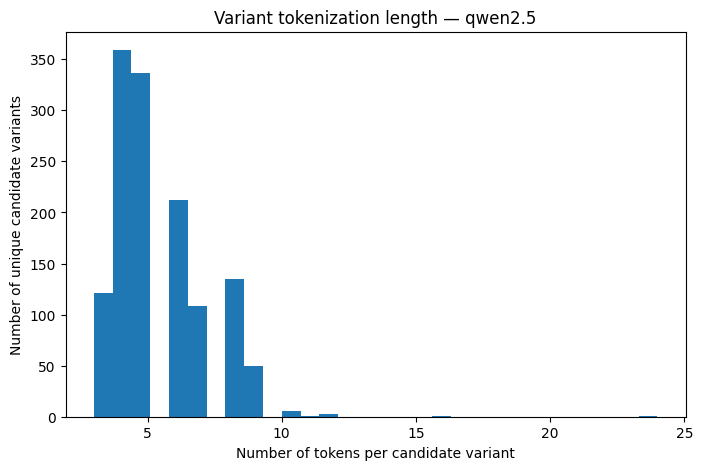

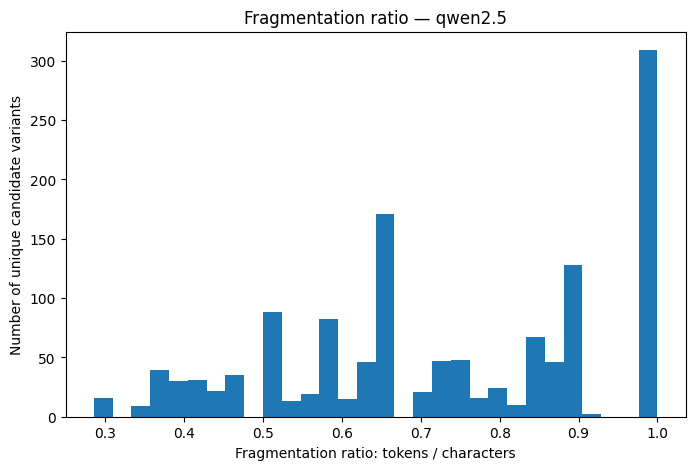

In [31]:
if len(candidate_features):
    plt.figure(figsize=(8, 5))
    plt.hist(candidate_features["n_tokens_raw"].dropna(), bins=30)
    plt.xlabel("Number of tokens per candidate variant")
    plt.ylabel("Number of unique candidate variants")
    plt.title(f"Variant tokenization length — {MAIN_TOKENIZER_KEY}")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(candidate_features["fragmentation_ratio"].dropna(), bins=30)
    plt.xlabel("Fragmentation ratio: tokens / characters")
    plt.ylabel("Number of unique candidate variants")
    plt.title(f"Fragmentation ratio — {MAIN_TOKENIZER_KEY}")
    plt.show()
else:
    print("No candidate features to plot.")


In [32]:
if len(candidate_features):
    summary_by_type = (
        candidate_features
        .assign(match_type_first=lambda d: d["match_type"].str.split(";").str[0])
        .groupby("match_type_first")
        .agg(
            n_variants=("variant", "count"),
            mean_tokens=("n_tokens_raw", "mean"),
            median_tokens=("n_tokens_raw", "median"),
            max_tokens=("n_tokens_raw", "max"),
            mean_fragmentation=("fragmentation_ratio", "mean"),
        )
        .sort_values("mean_tokens", ascending=False)
    )
    display(summary_by_type)
else:
    print("No candidate features available.")


,n_variants,mean_tokens,median_tokens,max_tokens,mean_fragmentation
match_type_first,,,,,
refseq_hgvs,2,20.000000,20.0,24,0.796053
coding_indel,14,8.714286,8.0,12,0.768981
rs_id,161,7.633540,8.0,10,0.880871
coding_substitution,30,7.400000,7.0,8,0.880423
protein_three_letter,13,6.615385,7.0,8,0.616317
protein_one_letter_with_p,32,6.000000,6.0,7,0.855655
gene_plus_protein,766,5.225849,5.0,11,0.587548
protein_one_letter,309,4.103560,4.0,7,1.000000
legacy_indel,7,3.857143,3.0,6,0.542857


## 8. Compare tokenizers

This lets you check whether the same variants are more or less fragmented depending on the tokenizer/model family.

If a tokenizer is gated or unavailable, the notebook skips it and continues.


In [ ]:
def load_tokenizer_safely(name):
    try:
        tok = AutoTokenizer.from_pretrained(name, use_fast=True, trust_remote_code=True)
        return tok, None
    except Exception as e:
        return None, str(e)

# Compare on candidate variants if available; otherwise use the manual examples.
if len(candidate_features):
    variants_for_comparison = candidate_features.head(100)["variant"].tolist()
else:
    variants_for_comparison = manual_variants

comparison_rows = []
load_errors = {}

for tok_key, tok_name in TOKENIZER_NAMES.items():
    print("Loading:", tok_key, tok_name)
    tok, err = load_tokenizer_safely(tok_name)
    if tok is None:
        load_errors[tok_key] = err
        print("  skipped:", err[:300])
        continue

    for v in tqdm(variants_for_comparison, desc=tok_key):
        feats = tokenization_features(v, tok)
        comparison_rows.append({
            "tokenizer_key": tok_key,
            "tokenizer_name": tok_name,
            "variant": v,
            "n_tokens_raw": feats["n_tokens_raw"],
            "chars_per_token_raw": feats["chars_per_token_raw"],
            "fragmentation_ratio": feats["fragmentation_ratio"],
            "tokens_raw": feats["tokens_raw"],
        })

comparison_df = pd.DataFrame(comparison_rows)

if load_errors:
    print("\nTokenizer load errors:")
    for k, e in load_errors.items():
        print(f"- {k}: {e[:500]}")

if len(comparison_df):
    display(comparison_df.sort_values(["variant", "n_tokens_raw"]))
else:
    print("No tokenizer comparison results.")


In [ ]:
if len(comparison_df):
    tokenizer_summary = (
        comparison_df
        .groupby("tokenizer_key")
        .agg(
            n_variants=("variant", "count"),
            mean_tokens=("n_tokens_raw", "mean"),
            median_tokens=("n_tokens_raw", "median"),
            max_tokens=("n_tokens_raw", "max"),
            mean_fragmentation=("fragmentation_ratio", "mean"),
        )
        .sort_values("mean_tokens")
    )
    display(tokenizer_summary)

    out_file = OUTPUT_DIR / "tokenizer_comparison.csv"
    save_df = comparison_df.copy()
    save_df["tokens_raw"] = save_df["tokens_raw"].apply(lambda x: json.dumps(x, ensure_ascii=False))
    save_df.to_csv(out_file, index=False)
    print("Saved:", out_file.resolve())
else:
    print("No comparison dataframe available.")


## 9. Inspect one candidate in context

Use this when you see a highly fragmented candidate and want to inspect where it appears in the text.


In [ ]:
# Change this to inspect a specific variant from candidate_features
VARIANT_TO_INSPECT = None

if VARIANT_TO_INSPECT is None and len(candidate_features):
    VARIANT_TO_INSPECT = candidate_features.iloc[0]["variant"]

print("Variant to inspect:", VARIANT_TO_INSPECT)

if VARIANT_TO_INSPECT is not None and len(candidates):
    rows = candidates[candidates["candidate_variant"].astype(str).eq(str(VARIANT_TO_INSPECT))]
    display(rows[[ID_COL, "candidate_variant", "match_type", "context"]].head(10))
    display(inspect_tokenization(VARIANT_TO_INSPECT, tokenizer))


## 10. Optional: create your own variant list

If you already have a list of variants from another source, paste them here and run the same tokenization analysis.


In [ ]:
my_variants = [
    # Paste variants here, for example:
    # "V600E",
    # "c.1799T>A",
    # "NM_004333.6:c.1799T>A",
]

if my_variants:
    my_variant_features = pd.DataFrame([tokenization_features(v, tokenizer) for v in my_variants])
    display(my_variant_features[[
        "variant", "n_chars", "n_tokens_raw", "chars_per_token_raw",
        "fragmentation_ratio", "tokens_raw", "pieces_raw"
    ]])
else:
    print("No manual variants inserted yet.")


## 11. How to interpret the results

Useful signals:

- many tokens for a short variant means high fragmentation;
- HGVS-like syntax with `.`, `_`, `>`, `:`, `/`, `del`, `dup`, `ins` often fragments heavily;
- variants with reference-sequence prefixes such as `NM_004333.6:c.1799T>A` may be harder than compact forms like `V600E`;
- compare tokenizers using `mean_tokens`, `median_tokens`, and the most fragmented examples.

What this notebook can tell you now:

- which variant formats are tokenized poorly;
- whether your corpus contains many such variants;
- which tokenizer handles your variant strings more compactly.

What it cannot tell you yet without `LLM_evaluation_statistics.csv`:

- whether those fragmented variants are specifically false negatives;
- whether recall is statistically lower for fragmented variants.

Once you receive the evaluation file, you can merge model outcomes with these tokenization features and compare TP vs FN cases.
